<a href="https://colab.research.google.com/github/aminsiddik2810/data-science-2026/blob/https%2Fgithub.com%2Faminsiddik2810%2Fdata-science-2026.git/Pertemuan12_AminSiddikRangkuti_220401010124.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science — Pertemuan 12: Asosiasi Data dan Sistem Rekomendasi Dasar

## Identitas Mahasiswa

**Nama:** Amin Siddik Rangkuti  
**NIM:** 220401010124  
**Kelas:** IF405  
**Program Studi:** PJJ Informatika  
**Mata Kuliah:** Data Science  
**Universitas:** Universitas Siber Asia

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aminsiddik2810/data-science-2026/blob/main/Pertemuan12_AminSiddikRangkuti_220401010124.ipynb)

## Langkah 0 – Instalasi Library
Library `mlxtend` digunakan untuk menjalankan algoritma Apriori dan membuat aturan asosiasi.

In [1]:
# Notebook ini menggunakan implementasi Apriori sederhana berbasis Python standar
print('Library siap: pandas, numpy, matplotlib, scikit-learn')

Library siap: pandas, numpy, matplotlib, scikit-learn


## Langkah 1 – Generate dan Eksplorasi Dataset Transaksi
Dataset transaksi dibuat secara sintetis menggunakan pola pembelian tersembunyi. Produk **Roti** dibuat cenderung muncul bersama **Selai** agar terbentuk pola asosiasi yang dapat ditemukan oleh algoritma Apriori.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, setiap transaksi berisi 2–5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Contoh transaksi:')
for i, trx in enumerate(transaksi[:5], start=1):
    print(f'Transaksi {i}: {trx}')

print('\nJumlah transaksi:', len(transaksi))

Contoh transaksi:
Transaksi 1: [np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai']
Transaksi 2: [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')]
Transaksi 3: [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]
Transaksi 4: [np.str_('Selai'), np.str_('Keju'), np.str_('Telur'), np.str_('Teh')]
Transaksi 5: [np.str_('Mentega'), np.str_('Susu'), np.str_('Gula'), np.str_('Keju')]

Jumlah transaksi: 50


### Eksplorasi Frekuensi Produk
Frekuensi setiap produk dihitung untuk melihat item yang paling sering muncul dalam transaksi.

,Frekuensi
Selai,26
Teh,23
Mentega,21
Telur,18
Keju,17
Roti,16
Kopi,16
Susu,16
Gula,16
Sereal,9


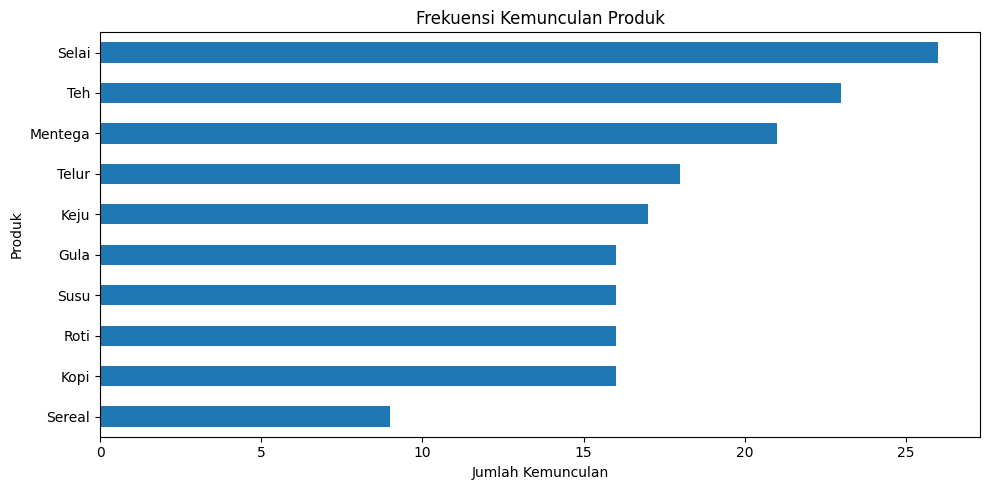

In [3]:
frekuensi_produk = pd.Series(
    [item for trx in transaksi for item in trx]
).value_counts()

display(frekuensi_produk.to_frame('Frekuensi'))

plt.figure(figsize=(10, 5))
frekuensi_produk.sort_values().plot(kind='barh')
plt.title('Frekuensi Kemunculan Produk')
plt.xlabel('Jumlah Kemunculan')
plt.ylabel('Produk')
plt.tight_layout()
plt.show()

## Langkah 2 – One-Hot Encoding Transaksi
Daftar transaksi diubah menjadi tabel one-hot encoding menggunakan `TransactionEncoder`. Nilai `True` berarti produk terdapat dalam transaksi, sedangkan `False` berarti produk tidak terdapat dalam transaksi.

In [4]:
# One-hot encoding transaksi tanpa library tambahan
df = pd.DataFrame(False, index=range(len(transaksi)), columns=sorted(produk))
for i, trx in enumerate(transaksi):
    df.loc[i, trx] = True

print('Ukuran data one-hot:', df.shape)
display(df.head(10))

Ukuran data one-hot: (50, 10)


,Gula,Keju,Kopi,Mentega,Roti,Selai,Sereal,Susu,Teh,Telur
0,False,True,True,True,True,True,False,False,False,False
1,False,False,True,True,True,True,False,False,True,False
2,False,False,True,False,False,False,False,True,True,False
3,False,True,False,False,False,True,False,False,True,True
4,True,True,False,True,False,False,False,True,False,False
5,True,False,False,True,True,True,False,False,False,False
6,False,True,False,True,False,False,False,False,True,True
7,True,False,False,False,True,True,False,True,False,False
8,False,False,False,False,False,False,False,True,True,True
9,False,False,True,False,False,False,False,True,False,False


## Langkah 3 – Mencari Frequent Itemset dengan Apriori
Algoritma Apriori dijalankan menggunakan beberapa nilai `min_support` untuk melihat pengaruh ambang batas support terhadap jumlah frequent itemset yang terbentuk.

In [5]:
from itertools import combinations

def apriori_sederhana(data_bool, min_support=0.1, max_len=3):
    transaksi_set = [set(data_bool.columns[row.values]) for _, row in data_bool.iterrows()]
    items = sorted(data_bool.columns)
    hasil = []
    n = len(transaksi_set)
    for k in range(1, max_len + 1):
        for combo in combinations(items, k):
            itemset = frozenset(combo)
            support = sum(itemset.issubset(t) for t in transaksi_set) / n
            if support >= min_support:
                hasil.append({'support': support, 'itemsets': itemset})
    return pd.DataFrame(hasil)

hasil_support = []
for ms in [0.05, 0.10, 0.20]:
    freq = apriori_sederhana(df, min_support=ms, max_len=3)
    hasil_support.append({'min_support': ms, 'jumlah_itemset': len(freq)})
    print(f'min_support={ms:.2f} -> {len(freq)} itemset ditemukan')

display(pd.DataFrame(hasil_support))

min_support=0.05 -> 74 itemset ditemukan
min_support=0.10 -> 44 itemset ditemukan
min_support=0.20 -> 13 itemset ditemukan


,min_support,jumlah_itemset
0,0.05,74
1,0.10,44
2,0.20,13


In [6]:
# Gunakan min_support yang menghasilkan jumlah itemset wajar
freq_items = apriori_sederhana(df, min_support=0.10, max_len=3)
freq_items = freq_items.sort_values('support', ascending=False).reset_index(drop=True)

display(freq_items.head(15))

,support,itemsets
0,0.52,(Selai)
1,0.46,(Teh)
2,0.42,(Mentega)
3,0.36,(Telur)
4,0.34,(Keju)
5,0.32,(Gula)
6,0.32,(Kopi)
7,0.32,(Roti)
8,0.32,(Susu)
9,0.24,"(Teh, Selai)"


### Analisis Min Support
- Nilai `min_support` yang kecil menghasilkan lebih banyak itemset, tetapi sebagian dapat berupa pola yang lemah atau noise.
- Nilai `min_support` yang besar menghasilkan lebih sedikit itemset dan dapat melewatkan pola penting.
- Pada praktikum ini digunakan `min_support = 0.10` agar jumlah itemset tetap cukup banyak tetapi masih mudah dianalisis.

## Langkah 4 – Membentuk dan Menyaring Aturan Asosiasi
Aturan asosiasi dibentuk dari frequent itemset, kemudian disaring menggunakan `confidence` dan `lift`. Aturan dengan `lift > 1` menunjukkan hubungan positif antara antecedent dan consequent.

In [7]:
# Membentuk association rules dari frequent itemset
support_map = {row['itemsets']: row['support'] for _, row in freq_items.iterrows()}
rules_list = []
for itemset, support_xy in support_map.items():
    if len(itemset) < 2:
        continue
    for r in range(1, len(itemset)):
        for antecedent_tuple in combinations(itemset, r):
            antecedent = frozenset(antecedent_tuple)
            consequent = itemset - antecedent
            support_x = support_map.get(antecedent)
            support_y = support_map.get(consequent)
            if support_x and support_y:
                confidence = support_xy / support_x
                lift = confidence / support_y
                if confidence >= 0.5 and lift > 1:
                    rules_list.append({
                        'antecedents': antecedent,
                        'consequents': consequent,
                        'support': support_xy,
                        'confidence': confidence,
                        'lift': lift
                    })

rules = pd.DataFrame(rules_list)
if not rules.empty:
    rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

kolom_tampil = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
display(rules[kolom_tampil].head(15) if not rules.empty else rules)

,antecedents,consequents,support,confidence,lift
0,"(Keju, Teh)",(Telur),0.12,0.857143,2.380952
1,"(Mentega, Selai)",(Kopi),0.10,0.625000,1.953125
2,"(Gula, Roti)",(Selai),0.10,1.000000,1.923077
3,(Sereal),(Mentega),0.14,0.777778,1.851852
4,"(Telur, Teh)",(Keju),0.12,0.600000,1.764706
5,"(Kopi, Selai)",(Mentega),0.10,0.714286,1.700680
6,"(Keju, Telur)",(Teh),0.12,0.750000,1.630435
7,"(Gula, Selai)",(Roti),0.10,0.500000,1.562500
8,"(Kopi, Mentega)",(Selai),0.10,0.714286,1.373626
9,(Roti),(Selai),0.22,0.687500,1.322115


### Interpretasi Aturan Terkuat
Aturan dengan nilai `lift` tertinggi merupakan aturan yang hubungan antara antecedent dan consequent-nya paling kuat dibandingkan jika kedua item muncul secara independen.

In [8]:
if not rules.empty:
    aturan_terkuat = rules.iloc[0]
    print('Aturan terkuat:')
    print(f"Antecedent : {set(aturan_terkuat['antecedents'])}")
    print(f"Consequent : {set(aturan_terkuat['consequents'])}")
    print(f"Support    : {aturan_terkuat['support']:.3f}")
    print(f"Confidence : {aturan_terkuat['confidence']:.3f}")
    print(f"Lift       : {aturan_terkuat['lift']:.3f}")
else:
    print('Tidak ada aturan yang memenuhi confidence >= 0.5 dan lift > 1.')

Aturan terkuat:
Antecedent : {'Keju', 'Teh'}
Consequent : {'Telur'}
Support    : 0.120
Confidence : 0.857
Lift       : 2.381


## Langkah 5 – Rekomendasi Sederhana dengan Content-Based Filtering
Sistem rekomendasi Content-Based Filtering merekomendasikan produk berdasarkan kemiripan kategori produk. Data kategori diubah menjadi one-hot encoding, lalu kemiripan dihitung menggunakan cosine similarity.

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    'produk': ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
               'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega'],
    'kategori': ['Bakery', 'Bakery', 'Dairy', 'Cereal', 'Protein',
                 'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy']
})

fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

display(katalog)
display(pd.DataFrame(sim_matrix, index=katalog['produk'], columns=katalog['produk']))

,produk,kategori
0,Roti,Bakery
1,Selai,Bakery
2,Susu,Dairy
3,Sereal,Cereal
4,Telur,Protein
5,Keju,Dairy
6,Kopi,Minuman
7,Gula,Bumbu
8,Teh,Minuman
9,Mentega,Dairy


produk,Roti,Selai,Susu,Sereal,Telur,Keju,Kopi,Gula,Teh,Mentega
produk,,,,,,,,,,
Roti,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Selai,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Susu,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
Sereal,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Telur,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Keju,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
Kopi,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
Gula,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Teh,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [10]:
def rekomendasi_serupa(nama_produk, top_n=3):
    if nama_produk not in katalog['produk'].values:
        return f'Produk {nama_produk} tidak ditemukan.'

    idx = katalog.index[katalog['produk'] == nama_produk][0]
    skor = list(enumerate(sim_matrix[idx]))
    skor = sorted(skor, key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]

    hasil = katalog.iloc[[i for i, _ in skor]][['produk', 'kategori']].copy()
    hasil['similarity'] = [nilai for _, nilai in skor]
    return hasil

print("Rekomendasi produk yang mirip dengan 'Roti':")
display(rekomendasi_serupa('Roti'))

Rekomendasi produk yang mirip dengan 'Roti':


,produk,kategori,similarity
1,Selai,Bakery,1.0
2,Susu,Dairy,0.0
3,Sereal,Cereal,0.0


## Langkah 6 – Membandingkan Kedua Pendekatan
Pada langkah ini, rekomendasi dari aturan asosiasi dibandingkan dengan hasil Content-Based Filtering untuk produk target **Roti**.

In [11]:
produk_target = 'Roti'

# Rekomendasi dari association rules
rules_target = rules[
    rules['antecedents'].apply(lambda x: produk_target in x)
]

rekomendasi_rules = []
for itemset in rules_target['consequents']:
    rekomendasi_rules.extend(list(itemset))

rekomendasi_rules = list(dict.fromkeys(rekomendasi_rules))

print('Rekomendasi dari Association Rules:')
print(rekomendasi_rules[:5] if rekomendasi_rules else 'Tidak ada rekomendasi')

print('\nRekomendasi dari Content-Based Filtering:')
display(rekomendasi_serupa(produk_target))

Rekomendasi dari Association Rules:
['Selai']

Rekomendasi dari Content-Based Filtering:


,produk,kategori,similarity
1,Selai,Bakery,1.0
2,Susu,Dairy,0.0
3,Sereal,Cereal,0.0


### Analisis Perbandingan

**Association Rules** menghasilkan rekomendasi berdasarkan pola produk yang benar-benar sering dibeli bersama dalam transaksi. Hasilnya dipengaruhi oleh nilai support, confidence, dan lift.

**Content-Based Filtering** menghasilkan rekomendasi berdasarkan kesamaan kategori atau atribut produk. Pendekatan ini tetap dapat bekerja walaupun belum tersedia banyak transaksi pengguna.

Hasil kedua metode tidak selalu konsisten karena sumber informasinya berbeda. Association Rules menggunakan pola pembelian, sedangkan Content-Based Filtering menggunakan atribut produk. Keduanya dapat digabungkan menjadi sistem **hybrid** agar rekomendasi lebih lengkap dan relevan.

## Kesimpulan

Pada Pertemuan 12, saya mempelajari **Apriori** untuk menemukan frequent itemset dan membentuk association rules pada Market Basket Analysis, serta konsep sistem rekomendasi sederhana menggunakan **Content-Based Filtering**. Support menunjukkan frekuensi kemunculan itemset, confidence menunjukkan kekuatan aturan, dan lift membantu menilai apakah hubungan antar-item lebih kuat dibandingkan kondisi independen.

Temuan utama menunjukkan bahwa nilai `min_support` memengaruhi jumlah pola yang ditemukan: nilai terlalu kecil dapat menghasilkan banyak pola lemah, sedangkan nilai terlalu besar dapat menghilangkan pola penting. Association Rules cocok untuk pola pembelian bersama, sedangkan Content-Based Filtering menggunakan kemiripan atribut item.

**Keterbatasan:** transaksi dan katalog pada praktikum masih bersifat sintetis dan sederhana. Pengembangan berikutnya dapat menggunakan transaksi nyata, menguji nilai threshold yang berbeda, serta membandingkan Content-Based Filtering dengan Collaborative Filtering atau pendekatan hybrid.